In [1]:
import json
import pandas as pd
import re
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
keypoint_selection = "coco"  # Options: "coco" or "vitpose"

In [3]:
with open(f"../{keypoint_selection}/curriculum_data/atomic_items.json", 'r') as f:
    atomic_items= json.load(f)

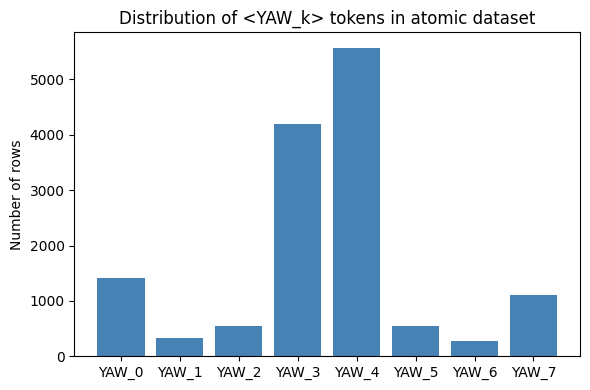

In [4]:
rows = atomic_items
yaw_pat = re.compile(r"<YAW_(\d)>")
counts  = [0]*8                     # bins 0 … 7

for ex in rows:
    m = yaw_pat.search(ex["conversations"][1]["value"])
    if m:
        counts[int(m.group(1))] += 1

# ------- 3.  Plot -----------------------------------------------------
plt.figure(figsize=(6,4))
plt.bar(range(8), counts, color="steelblue")
plt.xticks(range(8), [f"YAW_{k}" for k in range(8)])
plt.ylabel("Number of rows")
plt.title("Distribution of <YAW_k> tokens in atomic dataset")
plt.tight_layout()
plt.show()

In [5]:
# split data into yaw buckets so we can bin our CoT data accordingly
import random
rows = random.sample(rows, len(rows))

yaw_buckets = {}

for yaw in range(8):
    yaw_rows = [ex for ex in rows if yaw_pat.search(ex["conversations"][1]["value"]).group(1) == str(yaw)]
    yaw_rows = yaw_rows[:1000]  # limit to 1000 examples
    yaw_buckets[f"YAW_{yaw}"] = yaw_rows

In [6]:
# print example
yaw_buckets["YAW_0"][1]

{'id': '12656',
 'image': '000000400253.jpg',
 'conversations': [{'from': 'human',
   'value': "<image>\nEstimate this person's pose."},
  {'from': 'gpt',
   'value': '<POSE_START><SHOULDER_L><X_35><Y_188><SHOULDER_R><X_94><Y_176><HIP_L><X_55><Y_326><HIP_R><X_97><Y_326><ORIENT_START><YAW_0><TORSO_W_3><ORIENT_END><POSE_END>'}]}

In [7]:
import json, random
from pathlib import Path
from PIL import Image

IMG_DIR       = Path("../data/images")
STORE_FILE    = Path(f"../{keypoint_selection}/cot_selection.json") # change if you'd like to create new CoT data
MIN_KEEP      = 10           # for yaw 0,1,6,7
MIN_FLIP      = 15           # for yaw 2,3,4,5

# ------------------ load or init the storage dict-of-lists ---------
if STORE_FILE.exists():
    image_dirs = json.load(STORE_FILE.open())
else:
    image_dirs = {
        "yaw"            : [],
        "image_name"     : [],
        "item_name"      : [],
        "image_direct"   : [],
        "persp_direction": [],
        "tokens"         : []
    }

# ------------------ quick lookup dict for O(1) duplicate test ------
seen = {name: idx for idx, name in enumerate(image_dirs["image_name"])}

# ------------------ helper to count rows already stored ------------
def current_counts(bucket):
    left = right = 0
    for y, pt in zip(image_dirs["yaw"], image_dirs["persp_direction"]):
        if y == bucket:
            if pt == "left":  left  += 1
            else:             right += 1
    return left, right

# ------------------ main loop --------------------------------------
for bucket, examples in yaw_buckets.items():
    tgt = MIN_KEEP if bucket in {"YAW_0","YAW_1","YAW_6","YAW_7"} else MIN_FLIP
    left_count, right_count = current_counts(bucket)

    print(f"\nBucket {bucket}: starting  left={left_count}, right={right_count}")

    # shuffle examples
    random.shuffle(examples)

    for ex in examples:
        img_name = ex["image"]

        # ------------ already labelled?  just update counters -------
        if img_name in seen:
            idx = seen[img_name]
            if image_dirs["persp_direction"][idx] == "left":
                left_count  += 0   # already counted in current_counts()
            else:
                right_count += 0
            continue

        # ------------ stop criteria met? ----------------------------
        if left_count >= tgt and right_count >= tgt:
            print("  ✓ enough rows, moving to next bucket")
            break

        # ------------ show & label interactively --------------------
        Image.open(IMG_DIR / img_name).show()

        item_name        = input("Item name: ").strip()
        img_dir          = input("Image‑side (left/right): ").strip().lower()
        persp_direction  = input("Person‑side (left/right): ").strip().lower()

        if img_dir not in ("left","right") or persp_direction not in ("left","right"):
            print("  ↩  invalid entry, skipping")
            continue

        # update counts *only if we still need that side*
        if persp_direction == "left"  and left_count  >= tgt: continue
        if persp_direction == "right" and right_count >= tgt: continue

        # store the new annotation
        image_dirs["yaw"].append(bucket)
        image_dirs["image_name"].append(img_name)
        image_dirs["item_name"].append(item_name)
        image_dirs["image_direct"].append(img_dir)
        image_dirs["persp_direction"].append(persp_direction)
        image_dirs["tokens"].append(ex["conversations"][1]["value"])
        seen[img_name] = len(image_dirs["image_name"]) - 1

        if persp_direction == "left":
            left_count  += 1
        else:
            right_count += 1

        # save every 5 *new* rows
        if (left_count + right_count) % 5 == 0:
            with STORE_FILE.open("w") as f:
                json.dump(image_dirs, f, indent=2)
            print(f"  • saved ({left_count} L, {right_count} R)")

# final save
with STORE_FILE.open("w") as f:
    json.dump(image_dirs, f, indent=2)

print("\nAll buckets processed and saved.")


Bucket YAW_0: starting  left=10, right=10
  ✓ enough rows, moving to next bucket

Bucket YAW_1: starting  left=10, right=10
  ✓ enough rows, moving to next bucket

Bucket YAW_2: starting  left=15, right=15
  ✓ enough rows, moving to next bucket

Bucket YAW_3: starting  left=15, right=15
  ✓ enough rows, moving to next bucket

Bucket YAW_4: starting  left=15, right=15
  ✓ enough rows, moving to next bucket

Bucket YAW_5: starting  left=15, right=15
  ✓ enough rows, moving to next bucket

Bucket YAW_6: starting  left=10, right=10
  ✓ enough rows, moving to next bucket

Bucket YAW_7: starting  left=10, right=10
  ✓ enough rows, moving to next bucket

All buckets processed and saved.


In [8]:
# load image_dirs from file if it exists
if Path(STORE_FILE).exists():
    with open(STORE_FILE, 'r') as f:
        cot_binned_selections = json.load(f)

In [9]:
import pandas as pd

df = pd.DataFrame(cot_binned_selections)
df

,yaw,image_name,item_name,image_direct,persp_direction,tokens
0,YAW_0,000000280760.jpg,chair,left,left,<POSE_START><SHOULDER_L><X_224><Y_179><SHOULDE...
1,YAW_0,000000011737.jpg,baseball,left,left,<POSE_START><SHOULDER_L><X_204><Y_114><SHOULDE...
2,YAW_0,000000457678.jpg,fruit stand,left,left,<POSE_START><SHOULDER_L><X_283><Y_101><SHOULDE...
3,YAW_0,000000018179.jpg,train,right,right,<POSE_START><SHOULDER_L><X_45><Y_179><SHOULDER...
4,YAW_0,000000066662.jpg,minivan,left,left,<POSE_START><SHOULDER_L><X_196><Y_196><SHOULDE...
...,...,...,...,...,...,...
195,YAW_7,000000273002.jpg,chair,right,right,<POSE_START><SHOULDER_L><X_133><Y_90><SHOULDER...
196,YAW_7,000000244520.jpg,storage unit,left,left,<POSE_START><SHOULDER_L><X_155><Y_107><SHOULDE...
197,YAW_7,000000054692.jpg,vase,left,left,<POSE_START><SHOULDER_L><X_177><Y_56><SHOULDER...
198,YAW_7,000000324915.jpg,kite,right,right,<POSE_START><SHOULDER_L><X_132><Y_161><SHOULDE...


In [10]:
# check if there are any na values in the dataframe
df.isna().sum()

yaw                0
image_name         0
item_name          0
image_direct       0
persp_direction    0
tokens             0
dtype: int64

In [11]:
# group by yaw and persp_direction and count the number of rows
df.groupby(['yaw', 'persp_direction']).size().reset_index(name='counts')

,yaw,persp_direction,counts
0,YAW_0,left,10
1,YAW_0,right,10
2,YAW_1,left,10
3,YAW_1,right,10
4,YAW_2,left,15
5,YAW_2,right,15
6,YAW_3,left,15
7,YAW_3,right,15
8,YAW_4,left,15
9,YAW_4,right,15


#### Add CoT and direct items

In [12]:
def add_json_item(id, image, prompt, response):
    return {
        "id": id,
        "image": image,
        "conversations": [
            {
                "from": "human",
                "value": f"<image>\n{prompt}"
            },
            {
                "from": "gpt",
                "value": response
            }
        ]
    }

In [13]:
def gen_cot_prompt(item):
    return (f"A person and a {item} are shown in the image. Which side of the person is the {item} on from the person\u0027s perspective?\n"
            "To answer this question, let's think through it step by step, and we know the image is 336 x 336. "
            f"First, what is the {item}\u0027s position relative to the person from the viewer\u0027s frame?\n"
            "Second, what is the person\u0027s pose in token form?\n"
            "Third, from the pose, what is the person\u0027s orientation bin and do they face toward or away from the viewer?\n"
            f"Fourth, mentally rotate the viewer\u0027s frame to align with the person\u0027s orientation, what side of the person did the {item} end up on?\n")

def gen_cot_response(item, image_direction, pose_tokens, yaw, orientation, alignment, perspective_direction):
    return (f"The {item} is {image_direction} of the person from the viewer\u0027s frame. "
            f"The person\u0027s pose is {pose_tokens}. "
            f"Since <{yaw}> lies in the {orientation} bin, the person is {alignment}. "
            f"After performing a mental rotation of {orientation} degrees, the {item} is now to the {perspective_direction}. "
            f"Therefore, the {item} is to the {perspective_direction} from the perspective of the person.")

In [14]:
def gen_direct_prompt(item):
    return (f"A person and a {item} are shown in the image. Which side of the person is the {item} on from the person\u0027s perspective?")

In [15]:
cot_items = []
direct_items = []

cot_items_path = f"../{keypoint_selection}/curriculum_data/cot_items.json"
direct_items_path = f"../{keypoint_selection}/curriculum_data/direct_items.json"

In [ ]:
for i in range(len(df)):
    yaw = df.iloc[i]["yaw"]
    image_name = df.iloc[i]["image_name"]
    item_name = df.iloc[i]["item_name"]
    image_direction = df.iloc[i]["image_direct"]
    persp_direction = df.iloc[i]["persp_direction"]
    tokens = df.iloc[i]["tokens"]

    # define orientation based on yaw
    if yaw == "YAW_0":
        orientation = "0-45"
    elif yaw == "YAW_1":
        orientation = "45-90"
    elif yaw == "YAW_2":
        orientation = "90-135"
    elif yaw == "YAW_3":
        orientation = "135-180"
    elif yaw == "YAW_4":
        orientation = "180-225"
    elif yaw == "YAW_5":
        orientation = "225-270"
    elif yaw == "YAW_6":
        orientation = "270-315"
    elif yaw == "YAW_7":
        orientation = "315-360"

    # define alignment based on yaw
    alignment = "aligned" if yaw in ["YAW_0", "YAW_1", "YAW_6", "YAW_7"] else "unaligned"

    # generate the prompt and response
    cot_prompt = gen_cot_prompt(item_name)
    cot_response = gen_cot_response(item_name, image_direction, tokens, yaw, orientation, alignment, persp_direction)

    # add the item to the list
    cot_items.append(add_json_item(i, image_name, cot_prompt, cot_response))

    direct_prompt = gen_direct_prompt(item_name)
    direct_response = persp_direction

    direct_items.append(add_json_item(i, image_name, direct_prompt, direct_response))

In [ ]:
# save the items to json files
with open(cot_items_path, 'w') as f:
    json.dump(cot_items, f, indent=4)

with open(direct_items_path, 'w') as f:
    json.dump(direct_items, f, indent=4)

#### Text data

In [ ]:
cot_items_text = []

cot_items_text_path = f"../{keypoint_selection}/curriculum_data/cot_items_text.json"

In [17]:
text_tokens_path = f"../{keypoint_selection}/curriculum_data/atomic_items_text.json"
with open(text_tokens_path, 'r') as f:
    text_data = json.load(f)

text_df = pd.DataFrame(text_data)
text_df.head()

,id,image,conversations
0,00001,575933.jpg,"[{'from': 'human', 'value': '<image> Return th..."
1,00002,199481.jpg,"[{'from': 'human', 'value': '<image> Return th..."
2,00003,127834.jpg,"[{'from': 'human', 'value': '<image> What are ..."
3,00004,86250.jpg,"[{'from': 'human', 'value': '<image> Return th..."
4,00005,311796.jpg,"[{'from': 'human', 'value': '<image> Estimate ..."


In [ ]:
# add text_tokens column to the dataframe
text_df["text_tokens"] = text_df["conversations"].apply(lambda x: x[1]["value"])
# rename image to image_name
text_df.rename(columns={"image": "image_name"}, inplace=True)
text_df.head()

In [ ]:
# left join df, and text_df on image_name
df = df.merge(text_df[["image_name", "text_tokens"]], on="image_name", how="left")
df.head()

In [ ]:
for i in range(len(df)):
    yaw = df.iloc[i]["yaw"]
    yaw_int = yaw.replace("YAW_", "")
    image_name = df.iloc[i]["image_name"]
    item_name = df.iloc[i]["item_name"]
    image_direction = df.iloc[i]["image_direct"]
    persp_direction = df.iloc[i]["persp_direction"]
    tokens = df.iloc[i]["text_tokens"]

    # define orientation based on yaw
    if yaw == "YAW_0":
        orientation = "0-45"
    elif yaw == "YAW_1":
        orientation = "45-90"
    elif yaw == "YAW_2":
        orientation = "90-135"
    elif yaw == "YAW_3":
        orientation = "135-180"
    elif yaw == "YAW_4":
        orientation = "180-225"
    elif yaw == "YAW_5":
        orientation = "225-270"
    elif yaw == "YAW_6":
        orientation = "270-315"
    elif yaw == "YAW_7":
        orientation = "315-360"

    # define alignment based on yaw
    alignment = "aligned" if yaw in ["YAW_0", "YAW_1", "YAW_6", "YAW_7"] else "unaligned"

    # generate the prompt and response
    cot_prompt = gen_cot_prompt(item_name)
    cot_response = gen_cot_response(item_name, image_direction, tokens, yaw_int, orientation, alignment, persp_direction)

    # add the item to the list
    cot_items_text.append(add_json_item(i, image_name, cot_prompt, cot_response))

In [ ]:
with open(cot_items_text_path, 'w') as f:
    json.dump(cot_items_text, f, indent=4)